# Lecture 1 - PCA and Data Standardization

In [1]:
# Imports
from sklearn.datasets import load_iris # Data
import pandas as pd
import numpy as np

# Getting the iris df
df = load_iris(as_frame=True).frame

## Data Analysis and Preprocessing - PCA (Principle Component Analysis)

In [2]:
# SHowing the dataframe for review and overview properties
df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


In [3]:
# Splitting data into features and target

features_df = df.drop(['target'], axis = 1)
target_df = df['target']

## Standardizing Feature Data

Scale each feature value to have a mean of 0 and standard deviation of 1. *Important preprocessing step in most modeling/ml*.

Also called $Z$-Score Normalization in Statistics.

In [4]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# Standardization of data
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features_df)

# Not the same as Standard Scaler:
# standardized_data2 = (features_df - features_df.mean()) / features_df.std( (would be correct with .std(ddof=0)) ) (degrees of freedom)



## Normalization of Data

In [5]:
# Normalization - require all data to crushed inside a max min (usually 0-1) range
from sklearn.preprocessing import MinMaxScaler

# Convert all numbers from 0-1
normalizer = MinMaxScaler()
features_normalized = normalizer.fit_transform(features_df)
features_normalized

array([[0.22222222, 0.625     , 0.06779661, 0.04166667],
       [0.16666667, 0.41666667, 0.06779661, 0.04166667],
       [0.11111111, 0.5       , 0.05084746, 0.04166667],
       [0.08333333, 0.45833333, 0.08474576, 0.04166667],
       [0.19444444, 0.66666667, 0.06779661, 0.04166667],
       [0.30555556, 0.79166667, 0.11864407, 0.125     ],
       [0.08333333, 0.58333333, 0.06779661, 0.08333333],
       [0.19444444, 0.58333333, 0.08474576, 0.04166667],
       [0.02777778, 0.375     , 0.06779661, 0.04166667],
       [0.16666667, 0.45833333, 0.08474576, 0.        ],
       [0.30555556, 0.70833333, 0.08474576, 0.04166667],
       [0.13888889, 0.58333333, 0.10169492, 0.04166667],
       [0.13888889, 0.41666667, 0.06779661, 0.        ],
       [0.        , 0.41666667, 0.01694915, 0.        ],
       [0.41666667, 0.83333333, 0.03389831, 0.04166667],
       [0.38888889, 1.        , 0.08474576, 0.125     ],
       [0.30555556, 0.79166667, 0.05084746, 0.125     ],
       [0.22222222, 0.625     ,

## PCA - Correlation (Coefficient) Matrix for Feature Data Set

A matrix which indicated the correlation coefficients between multuple variables/features, showing how strongly pairs of variables/features are related.

- -1 indicates strong negative correlation
- 1 indicates strong positive correlation
- 0 indicates no correlation

In [6]:
# Use Numpy for it
np_ccm = np.corrcoef(features_df, rowvar=False)

- Syntax thing - functions like ```_get_p_val()``` *(with a leading underscore)* indicate that there are no checks - internal function only
- **Advice**: One return is better for maintance, try to do that

In [7]:
from scipy.stats import pearsonr
pearsonr([[2], [3]], [[2], [3]]) # Example col vecture, perfect correlation

PearsonRResult(statistic=array([5.]), pvalue=1.0)

Testing using Standardized Iris Data Set

Can figure this out later

In [8]:
# Ensure features_scaled is defined
std_sl = features_normalized[:, 0].reshape(-1, 1)  # Transposition to col vector
std_sw = features_normalized[:, 1].reshape(-1, 1)  # This gaurentees that they are column vectors (NEEDED)

pearsonr(std_sl, std_sw) # Should be the same as np_ccm[0, 1]

ValueError: shapes (150,1) and (150,1) not aligned: 1 (dim 1) != 150 (dim 0)

- Coefficient Matrix (CCM var name)


In [ ]:
pandas_ccm = features_df.corr()
pandas_ccm.to_numpy()

array([[ 1.        , -0.11756978,  0.87175378,  0.81794113],
       [-0.11756978,  1.        , -0.4284401 , -0.36612593],
       [ 0.87175378, -0.4284401 ,  1.        ,  0.96286543],
       [ 0.81794113, -0.36612593,  0.96286543,  1.        ]])

### Principle Components

The eigenvectors of he correlation coefficient matrix are the principle components of a given data set; the feature training data set in this case.

Each eigenvalue corresponding to a oprinciple components aigenvector represents a measure of variance determined by that eigenvector.

We use the Linear Algebra library numpy to determine the eigenvalues and aigenvectors of the training features data.

In [ ]:
''' We can use numpy np.linalg.eig to get the eigenvalues and eigenvectors of the correlation coefficient matrix '''
eigvals, eigvecs = np.linalg.eig(np_ccm)
eigvals, eigvecs

(array([2.91849782, 0.91403047, 0.14675688, 0.02071484]),
 array([[ 0.52106591, -0.37741762, -0.71956635,  0.26128628],
        [-0.26934744, -0.92329566,  0.24438178, -0.12350962],
        [ 0.5804131 , -0.02449161,  0.14212637, -0.80144925],
        [ 0.56485654, -0.06694199,  0.63427274,  0.52359713]]))

In [ ]:
''' This would help us determine different variances to help us choose which features to keep and which to drop '''
# Sort eigenvalues and vectors into descending order
sorted_indices = np.argsort(eigvals)[::-1]
sorted_eigvals = eigvals[sorted_indices]
sorted_eigvecs = eigvecs[:, sorted_indices]

sorted_eigvals, sorted_eigvecs

(array([2.91849782, 0.91403047, 0.14675688, 0.02071484]),
 array([[ 0.52106591, -0.37741762, -0.71956635,  0.26128628],
        [-0.26934744, -0.92329566,  0.24438178, -0.12350962],
        [ 0.5804131 , -0.02449161,  0.14212637, -0.80144925],
        [ 0.56485654, -0.06694199,  0.63427274,  0.52359713]]))

In [ ]:
print( sum(sorted_eigvals) ) # Should be equal to the number of features (4)

3.999999999999999


The **energy** of a principle component eigenvector is determined by dividing the eigenvalue corresponding to that eigenvector by the sum of all eigenvalues. Like normalizing the eigen values.

The **cumulative energy** is the sum of energies of the first $k$ principle components.

In [ ]:
# Culmulative Energy Calculation
total_variance = np.sum(sorted_eigvals)
energy = sorted_eigvals / total_variance

# Culmulative energy
cumulative_energy = np.cumsum(energy)
print (energy)  # All add to 1
print (cumulative_energy)  # Will "accumulate" to 1

NameError: name 'sorted_eigvals' is not defined

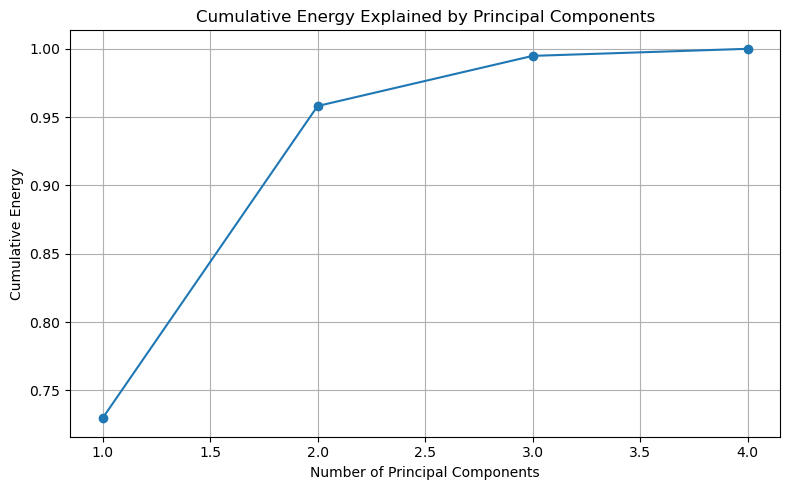

In [ ]:
''' Visualizing Cumulative Energy '''
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 5))
# plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.plot(range(1, len(cumulative_energy) + 1), cumulative_energy, marker='o')
plt.title('Cumulative Energy Explained by Principal Components')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Energy')
plt.grid(True)
plt.tight_layout()
plt.show()

Technical Detail - you *have* to do ```.copy()``` when making new var based on numpy array as it is sometimes called by reference.

In [ ]:
V_hat = sorted_eigvecs[:, :2].copy()  # Take the first 2 principal components (row 0,1) and make a copy (essential to not change original array)

X_train_hat = X_train @ V_hat  # Project the original data onto the new feature space

X_test_hat = X_test @ V_hat  # Project the test data onto the new feature space

Then, using this to train and test basic classifier